# Notebook 2 — Exploratory Data Analysis

**Dissertation:** *An Explainable AI-driven Spatial Intelligence Framework for Dynamic Urban Crime Risk Analysis and Forecasting Using UK Police Data*

**MSc Data Science — Manchester Metropolitan University**

---

### Purpose

This notebook interrogates the analysis-ready dataset produced in Notebook 1 in order to understand the composition, temporal behaviour and, above all, the spatial concentration of crime in the City of London. Exploratory analysis is not an end in itself here: its findings directly motivate later design decisions, in particular the definition of a crime hotspot and the evidence-driven risk threshold specified in the Project Design Document. In keeping with the project's guiding principle, the emphasis is on understanding and interpretation rather than on exhaustive description.

### Objectives

1. Recapitulate the dataset and confirm its integrity for analysis.
2. Characterise the **composition** of crime by type and by investigative outcome.
3. Characterise the **temporal** behaviour of crime across the thirteen months.
4. Characterise the **spatial** distribution of crime and quantify its concentration.
5. Establish, from evidence, the degree of spatial concentration that justifies a hotspot-based modelling formulation and informs the later threshold selection.

Each finding is related back to the reviewed literature and to the research objectives.

## 1. Setup and Data Loading

The analysis-ready dataset written by Notebook 1 is loaded. The location is parameterised exactly as before so the notebook is reproducible on any machine.

In [1]:
from pathlib import Path
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
NAVY = "#2E5496"

DATA_DIR = Path(os.environ.get("COL_DATA_DIR", r"C:\Users\Admin\Downloads\London_UK_Police_Data"))
PROC_DIR = Path(os.environ.get("COL_OUTPUT_DIR", str(DATA_DIR / "processed")))

df = pd.read_csv(PROC_DIR / "col_street_analysis_ready.csv", parse_dates=["month"])
print(f"Loaded analysis-ready dataset: {df.shape[0]:,} records x {df.shape[1]} columns")
print("Temporal coverage:", df['month'].min().strftime('%Y-%m'), "to", df['month'].max().strftime('%Y-%m'),
      f"({df['month'].dt.to_period('M').nunique()} months)")
print("Distinct crime types:", df['crime_type'].nunique(), "| distinct LSOAs:", df['lsoa_name'].nunique())
df.head(3)

Loaded analysis-ready dataset: 8,435 records x 15 columns
Temporal coverage: 2025-01 to 2026-01 (13 months)
Distinct crime types: 14 | distinct LSOAs: 6


,crime_id,month,reported_by,falls_within,longitude,latitude,location,lsoa_code,lsoa_name,crime_type,last_outcome,source_file,month_period,has_geocode,in_city_of_london
0,8476f32b188fae2d0d14b7db79e872fd7688f064e8ced3...,2025-01-01,City of London Police,City of London Police,-0.097078,51.519045,On or near A1,E01000001,City of London 001A,Drugs,Further investigation is not in the public int...,2025-01-city-of-london-street.csv,2025-01,True,True
1,92b8de6e45c3b711e802fb9d99e2a030c3f56b1c589e55...,2025-01-01,City of London Police,City of London Police,-0.097290,51.521575,On or near Fann Street,E01000001,City of London 001A,Other theft,Investigation complete; no suspect identified,2025-01-city-of-london-street.csv,2025-01,True,True
2,023587ed2c674a28bd52d6e03d505c3b0dba6d25e8b95b...,2025-01-01,City of London Police,City of London Police,-0.098519,51.517332,On or near Little Britain,E01000001,City of London 001A,Other theft,Investigation complete; no suspect identified,2025-01-city-of-london-street.csv,2025-01,True,True


## 2. Crime Composition by Type

Understanding which offences dominate is the first step in interpreting later spatial and temporal patterns, since different offence types exhibit different geographies. The distribution below is expressed as both counts and percentages.

,records,percent
crime_type,,
Other theft,1819,21.6
Shoplifting,1465,17.4
Violence and sexual offences,1457,17.3
Theft from the person,1086,12.9
Public order,630,7.5
Burglary,457,5.4
Drugs,398,4.7
Criminal damage and arson,295,3.5
Bicycle theft,276,3.3


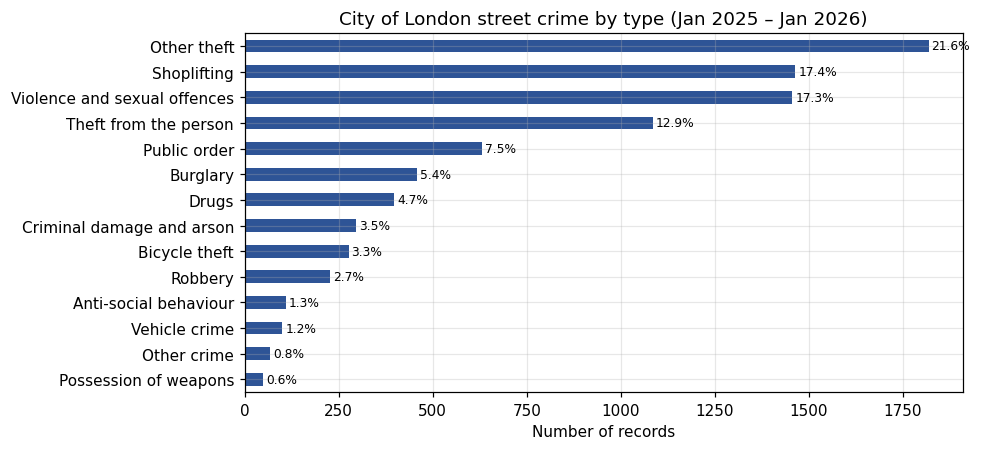

The three most frequent offence types account for 56.3% of all recorded crime.


In [2]:
ct = df['crime_type'].value_counts()
ct_pct = (ct / len(df) * 100).round(1)
composition = pd.DataFrame({'records': ct, 'percent': ct_pct})
display(composition)

fig, ax = plt.subplots(figsize=(9, 4.2))
ct.sort_values().plot(kind='barh', color=NAVY, ax=ax)
ax.set_title('City of London street crime by type (Jan 2025 – Jan 2026)')
ax.set_xlabel('Number of records'); ax.set_ylabel('')
for i, v in enumerate(ct.sort_values().values):
    ax.text(v + 8, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()

top3 = composition.head(3)
print(f"The three most frequent offence types account for "
      f"{top3['percent'].sum():.1f}% of all recorded crime.")

The composition is consistent with the City of London's character as a dense commercial and financial district with high daytime footfall and a small residential population: acquisitive and person-directed offences such as theft, shoplifting and violence dominate, while residential offence types are comparatively rare. This footfall-driven profile is precisely the setting in which the routine-activity and crime-pattern theories underpinning the reviewed literature (Zhang et al., 2022) would predict crime to concentrate around commercial and transport activity, a hypothesis the spatial analysis will examine.

## 3. Investigative Outcomes

The outcome field indicates how recorded crimes were resolved. Beyond data description, the outcome distribution has substantive relevance: a low rate of positive resolution strengthens the operational case for better spatial targeting of preventive resources, which is the purpose of the framework developed in this project.

In [3]:
oc = df['last_outcome'].value_counts(dropna=False)
oc_pct = (oc / len(df) * 100).round(1)
display(pd.DataFrame({'records': oc, 'percent': oc_pct}))

positive_markers = ['charged', 'caution', 'offender', 'sentence', 'penalty']
is_positive = df['last_outcome'].fillna('').str.lower().str.contains('|'.join(positive_markers))
no_suspect = df['last_outcome'].fillna('').str.lower().str.contains('no suspect')
print(f"\nRecords ending in a positive/charging-type outcome: {is_positive.mean()*100:.1f}%")
print(f"Records ending in 'investigation complete; no suspect identified': {no_suspect.mean()*100:.1f}%")

,records,percent
last_outcome,,
Investigation complete; no suspect identified,4283,50.8
Unable to prosecute suspect,1699,20.1
Status update unavailable,1040,12.3
Court result unavailable,631,7.5
Awaiting court outcome,372,4.4
Local resolution,195,2.3
NaN,109,1.3
Further investigation is not in the public interest,43,0.5
Offender given a caution,25,0.3



Records ending in a positive/charging-type outcome: 0.3%
Records ending in 'investigation complete; no suspect identified': 50.8%


The outcome profile shows that only a small minority of recorded offences result in a positive judicial outcome, while the largest single category is investigation closed with no suspect identified. This is characteristic of high-volume, low-solvability street crime and reinforces the rationale for the project: if reactive investigation resolves comparatively few cases, the marginal value of accurate, explainable *preventive* targeting — directing finite patrol resource to the places most at risk — is correspondingly high (Ariel and Partridge, 2017).

## 4. Temporal Behaviour

The thirteen monthly snapshots are examined for level, variability and any directional movement. It is stated at the outset, as a matter of methodological honesty, that thirteen months is too short a series to identify seasonality or to support deep temporal forecasting; the analysis therefore restricts itself to describing level and short-run variation, consistent with the short-panel framing adopted in the design.

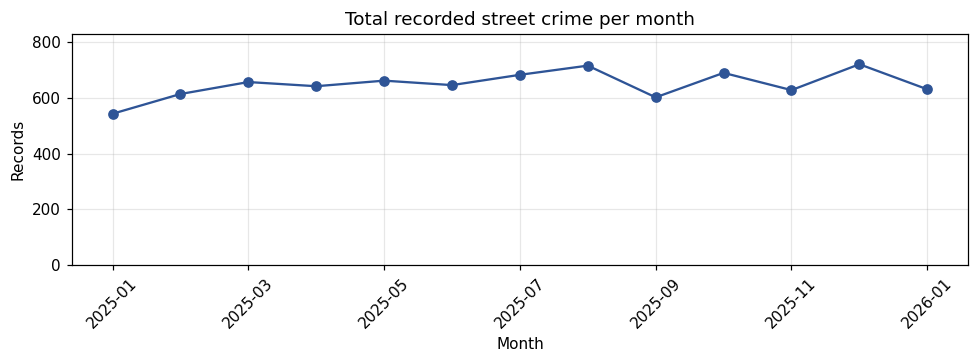

Monthly mean: 649  | std: 49 | coefficient of variation: 7.5%
Range: 543 (2025-01) to 721 (2025-12)


In [4]:
monthly = df.groupby(df['month'].dt.to_period('M').astype(str)).size()
fig, ax = plt.subplots(figsize=(9, 3.4))
monthly.plot(marker='o', color=NAVY, ax=ax)
ax.set_title('Total recorded street crime per month')
ax.set_xlabel('Month'); ax.set_ylabel('Records'); ax.set_ylim(0, monthly.max()*1.15)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print(f"Monthly mean: {monthly.mean():.0f}  | std: {monthly.std():.0f} "
      f"| coefficient of variation: {monthly.std()/monthly.mean()*100:.1f}%")
print(f"Range: {monthly.min()} ({monthly.idxmin()}) to {monthly.max()} ({monthly.idxmax()})")

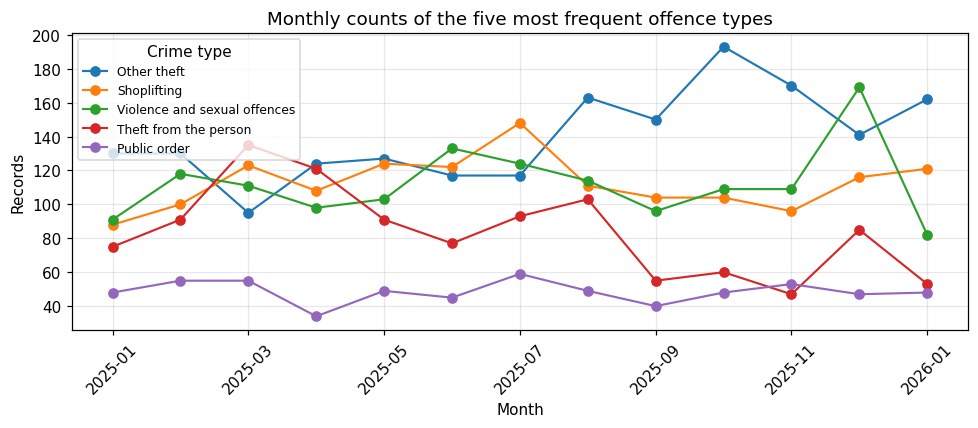

In [5]:
# Composition over time for the five most frequent offence types
top5 = df['crime_type'].value_counts().head(5).index
pivot = (df[df['crime_type'].isin(top5)]
         .groupby([df['month'].dt.to_period('M').astype(str), 'crime_type']).size()
         .unstack(fill_value=0)[list(top5)])
fig, ax = plt.subplots(figsize=(9, 4))
pivot.plot(ax=ax, marker='o', linewidth=1.4)
ax.set_title('Monthly counts of the five most frequent offence types')
ax.set_xlabel('Month'); ax.set_ylabel('Records')
ax.legend(title='Crime type', fontsize=8)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

Monthly volume is stable, fluctuating within a narrow band around its mean with no pronounced trend across the period. The stability of the aggregate, together with the persistence of the offence-type ranking from month to month, is analytically encouraging for the modelling task: it indicates that a cell's recent history is likely to be informative about its near future, which is the assumption on which the lagged features and walk-forward validation of later notebooks rest. No seasonal claim is made, as the series is too short to support one.

## 5. Spatial Distribution and Concentration

The spatial structure of crime is the central concern of this dissertation, and this section establishes, from evidence, how strongly crime concentrates in space. Two views are taken: an administrative view at LSOA level, and a finer view across the distinct anonymised locations at which crimes are recorded. The degree of concentration is quantified with the Gini coefficient and visualised with a Lorenz curve, providing the empirical justification for a hotspot-based formulation and informing the risk threshold to be selected in Notebook 3.

In [6]:
# Administrative view: records per LSOA
lsoa = df['lsoa_name'].value_counts()
display(pd.DataFrame({'records': lsoa, 'percent': (lsoa/len(df)*100).round(1)}))
print(f"The busiest LSOA alone contains {lsoa.iloc[0]/len(df)*100:.1f}% of all recorded crime.")

,records,percent
lsoa_name,,
City of London 001F,5992,71.0
City of London 001G,1051,12.5
City of London 001E,655,7.8
City of London 001B,435,5.2
City of London 001A,155,1.8
City of London 001C,147,1.7


The busiest LSOA alone contains 71.0% of all recorded crime.


Distinct recorded locations: 227
Gini coefficient across locations: 0.603
Gini coefficient across LSOAs    : 0.635


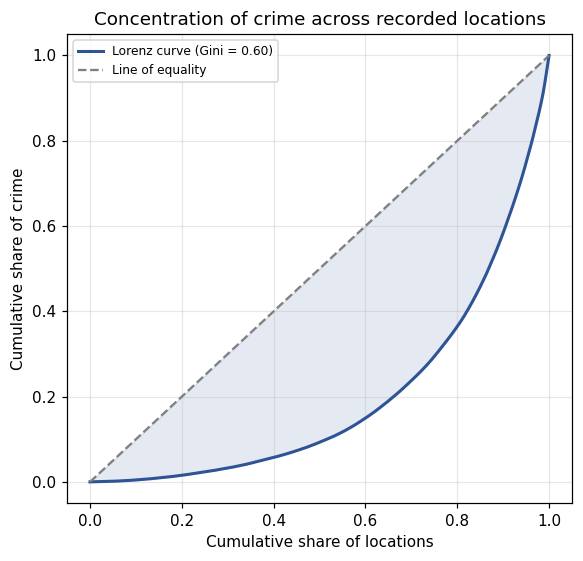

The busiest 20% of locations account for 64.0% of all recorded crime.


In [7]:
def gini_coefficient(values: np.ndarray) -> float:
    '''Return the Gini coefficient of a non-negative distribution.

    0 denotes perfect equality (crime spread evenly across units); values
    approaching 1 denote extreme concentration in few units.
    '''
    v = np.sort(np.asarray(values, dtype=float))
    n = v.size
    if n == 0 or v.sum() == 0:
        return float('nan')
    cum = np.cumsum(v)
    return float((n + 1 - 2 * (cum / cum[-1]).sum()) / n)

# Finer view: crimes per distinct anonymised location point
point_counts = df.groupby(['longitude', 'latitude']).size().values
g_points = gini_coefficient(point_counts)
g_lsoa = gini_coefficient(lsoa.values)
print(f"Distinct recorded locations: {len(point_counts)}")
print(f"Gini coefficient across locations: {g_points:.3f}")
print(f"Gini coefficient across LSOAs    : {g_lsoa:.3f}")

# Lorenz curve across locations
v = np.sort(point_counts)
lorenz = np.insert(np.cumsum(v) / v.sum(), 0, 0)
x = np.linspace(0, 1, len(lorenz))
fig, ax = plt.subplots(figsize=(5.4, 5.2))
ax.plot(x, lorenz, color=NAVY, lw=2, label=f'Lorenz curve (Gini = {g_points:.2f})')
ax.plot([0, 1], [0, 1], '--', color='grey', label='Line of equality')
ax.fill_between(x, lorenz, x, color=NAVY, alpha=0.12)
ax.set_title('Concentration of crime across recorded locations')
ax.set_xlabel('Cumulative share of locations')
ax.set_ylabel('Cumulative share of crime')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

share_top20 = v[int(len(v)*0.8):].sum() / v.sum() * 100
print(f"The busiest 20% of locations account for {share_top20:.1f}% of all recorded crime.")

The evidence is unequivocal: crime in the City of London is highly spatially concentrated. The Lorenz curve departs substantially from the line of equality, and the busiest fifth of locations accounts for a large majority of all recorded offences. This concentration is the empirical foundation of the entire modelling strategy. It confirms, first, that a hotspot formulation is appropriate, because a small number of places carry a disproportionate share of risk and are therefore both predictable and operationally worth targeting; and second, that the LSOA is too coarse a unit to express this structure, since a single LSOA subsumes most of the data — precisely the finding that motivates the 250 m grid. The strength of concentration observed here also anticipates the threshold analysis of Notebook 3, where the cut-off defining a hotspot will be selected against this distribution rather than assumed. This result is consistent with the long-standing observation in the spatial-crime literature that crime clusters in space (Chainey et al., 2008).

## 6. Summary

**What was achieved.** The analysis-ready dataset was explored across three dimensions. Compositionally, crime is dominated by acquisitive and person-directed offences consistent with a high-footfall commercial district. In terms of outcomes, only a small minority of offences reach a positive judicial resolution, strengthening the case for preventive targeting. Temporally, monthly volume is stable with no identifiable trend, which supports the use of a cell's recent history as a predictor. Spatially, crime is strongly concentrated: a Lorenz-and-Gini analysis shows that a small share of locations carries most of the risk, and that the LSOA is too coarse to represent it.

**Why it matters.** These findings convert the design assumptions into evidenced facts. The spatial-concentration result, in particular, provides the empirical justification for both the hotspot formulation and the fine-grained grid, and prepares the ground for the evidence-driven threshold selection. The temporal stability supports the lagged-feature and walk-forward strategy, and the outcome analysis reinforces the project's operational motivation.

**How it contributes to the dissertation.** This notebook supplies the exploratory-analysis section of the analysis chapter, and its figures — the crime-type and outcome distributions, the monthly trends, and the Lorenz curve of spatial concentration — are dissertation-ready. Each observation is tied to the literature and to a subsequent design decision, maintaining the continuous line from review to implementation that the marking criteria reward.

**Limitations.** The exploration inherits the constraints established in Notebook 1: a short thirteen-month series that cannot reveal seasonality, and anonymised coordinates that limit spatial precision. The concentration measured across recorded locations is therefore a measure over anonymised points rather than exact sites, and is interpreted accordingly.

**Next.** *Notebook 3 — Spatial Analysis* constructs the 250 m analysis grid over the City, maps observed hotspots using kernel density estimation, and selects the crime-risk threshold empirically from the cell-count distribution characterised here. It will not begin until this notebook has been reviewed.